<a href="https://colab.research.google.com/github/davronprogammer/Image_classification_garbage/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Yuklash
df = pd.read_csv('car_price.csv')

# Tanishish
print("Shape:", df.shape)
print("\n--- DTYPEs ---")
print(df.dtypes.value_counts())
print("\n--- BIRINCHI 5 QATOR ---")
df.head()

Shape: (8128, 12)

--- DTYPEs ---
object     6
int64      3
float64    3
Name: count, dtype: int64

--- BIRINCHI 5 QATOR ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [9]:
# --- MISSING VALUES ---
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Soni': missing, 'Foiz (%)': missing_pct})
print(miss_df[miss_df['Soni'] > 0].sort_values('Foiz (%)', ascending=False))

print("\n=== DF INFO ===")
df.info()

print("\n=== DESCRIBE ===")
df.describe()

=== MISSING VALUES ===
                    Soni  Foiz (%)
mileage(km/ltr/kg)   221      2.72
engine               221      2.72
seats                221      2.72
max_power            215      2.65

=== DF INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [10]:
# === 1. max_power: object → float (ichida matn bor) ===
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
print("max_power dtype:", df['max_power'].dtype)
print("max_power NaN soni:", df['max_power'].isnull().sum())

# === 2. Missing values to'ldirish ===
# Raqamli ustunlar — median bilan (chunki outlier bor, describe'da ko'rindi)
num_cols = ['mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: median={median_val:.2f} bilan to'ldirildi")

# === 3. Tekshirish ===
print("\n=== MISSING QOLGANMI? ===")
print(df.isnull().sum())

max_power dtype: float64
max_power NaN soni: 216
mileage(km/ltr/kg): median=19.30 bilan to'ldirildi
engine: median=1248.00 bilan to'ldirildi
max_power: median=82.00 bilan to'ldirildi
seats: median=5.00 bilan to'ldirildi

=== MISSING QOLGANMI? ===
name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64


In [11]:
# === 1. DUPLICATES ===
print("=== DUPLICATES ===")
print(f"Takroriy qatorlar soni: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Drop_duplicates keyin: {df.shape}")

# === 2. DTYPE TUZATISH ===
# engine va seats aslida int bo'lishi kerak
df['engine'] = df['engine'].astype(int)
df['seats'] = df['seats'].astype(int)

# year ham int (allaqachon int, lekin tekshiramiz)
print("\n=== DTYPES (tuzatilgan) ===")
print(df.dtypes)

# === 3. DESCRIBE — yangilangan ===
print("\n=== KATEGORIK USTUNLAR ===")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique")
    print(df[col].value_counts().head(4))

=== DUPLICATES ===
Takroriy qatorlar soni: 1202
Drop_duplicates keyin: (6926, 12)

=== DTYPES (tuzatilgan) ===
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                  int64
max_power             float64
seats                   int64
dtype: object

=== KATEGORIK USTUNLAR ===

name: 2058 unique
name
Maruti Swift Dzire VDI    118
Maruti Alto 800 LXI        76
Maruti Alto LXi            69
Maruti Swift VDI           60
Name: count, dtype: int64

fuel: 4 unique
fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64

seller_type: 3 unique
seller_type
Individual          6218
Dealer               681
Trustmark Dealer      27
Name: count, dtype: int64

transmission: 2 unique
transmission
Manual       6342
Automatic     584
N

=== OUTLIERS SONI (IQR) ===
selling_price: 328 outlier | chegara [-325250, 1208750]
km_driven: 167 outlier | chegara [-50000, 190000]
mileage(km/ltr/kg): 23 outlier | chegara [9, 30]
engine: 1207 outlier | chegara [746, 1950]
max_power: 374 outlier | chegara [22, 146]


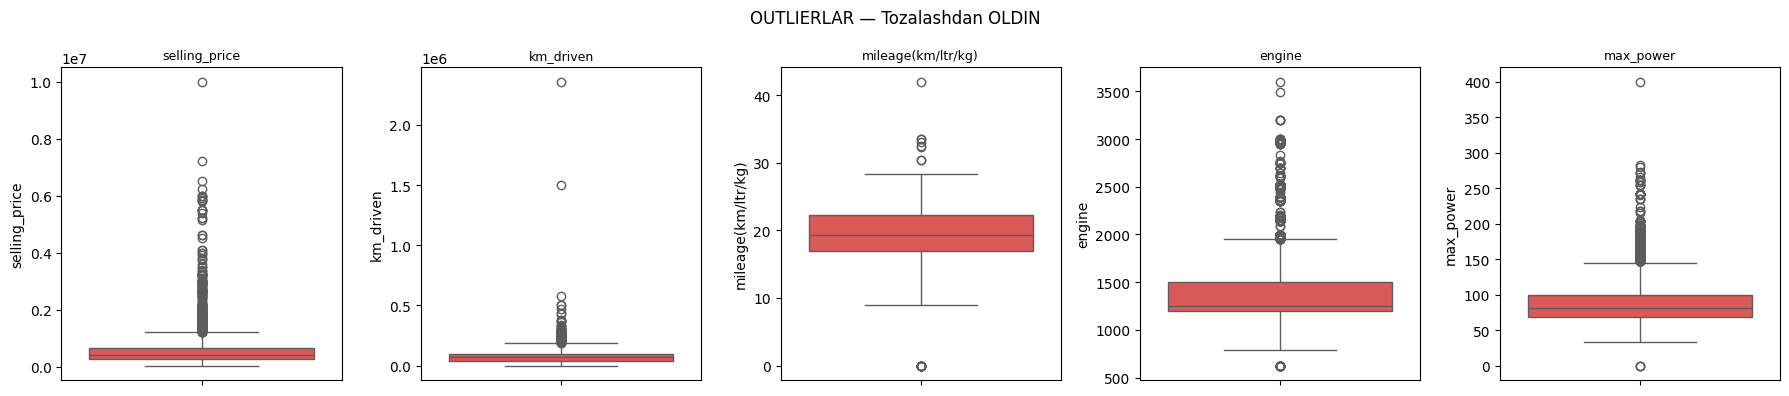

In [12]:
# === OUTLIERS — IQR metodi ===
num_cols = ['selling_price', 'km_driven', 'mileage(km/ltr/kg)',
            'engine', 'max_power']

print("=== OUTLIERS SONI (IQR) ===")
outlier_info = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_info[col] = len(outliers)
    print(f"{col}: {len(outliers)} outlier | chegara [{lower:.0f}, {upper:.0f}]")

# === BOXPLOT — tozalashdan OLDIN ===
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#EF4444')
    ax.set_title(col, fontsize=9)
plt.suptitle('OUTLIERLAR — Tozalashdan OLDIN', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# === FAQAT FEATURE ustunlarga IQR qo'llaymiz ===
# selling_price — O'ZGARTIRMAYMIZ (target)
# engine — ham o'zgartirmaymiz (1207 outlier juda ko'p,
#           sport mashinalar ham bor, real qiymatlar)

cols_to_clean = ['km_driven', 'mileage(km/ltr/kg)', 'max_power']

df_clean = df.copy()

print("Tozalashdan oldin:", df_clean.shape)

for col in cols_to_clean:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    print(f"{col}: {before - len(df_clean)} qator olib tashlandi")

print("\nTozalangandan keyin:", df_clean.shape)

Tozalashdan oldin: (6926, 12)
km_driven: 167 qator olib tashlandi
mileage(km/ltr/kg): 27 qator olib tashlandi
max_power: 361 qator olib tashlandi

Tozalangandan keyin: (6371, 12)


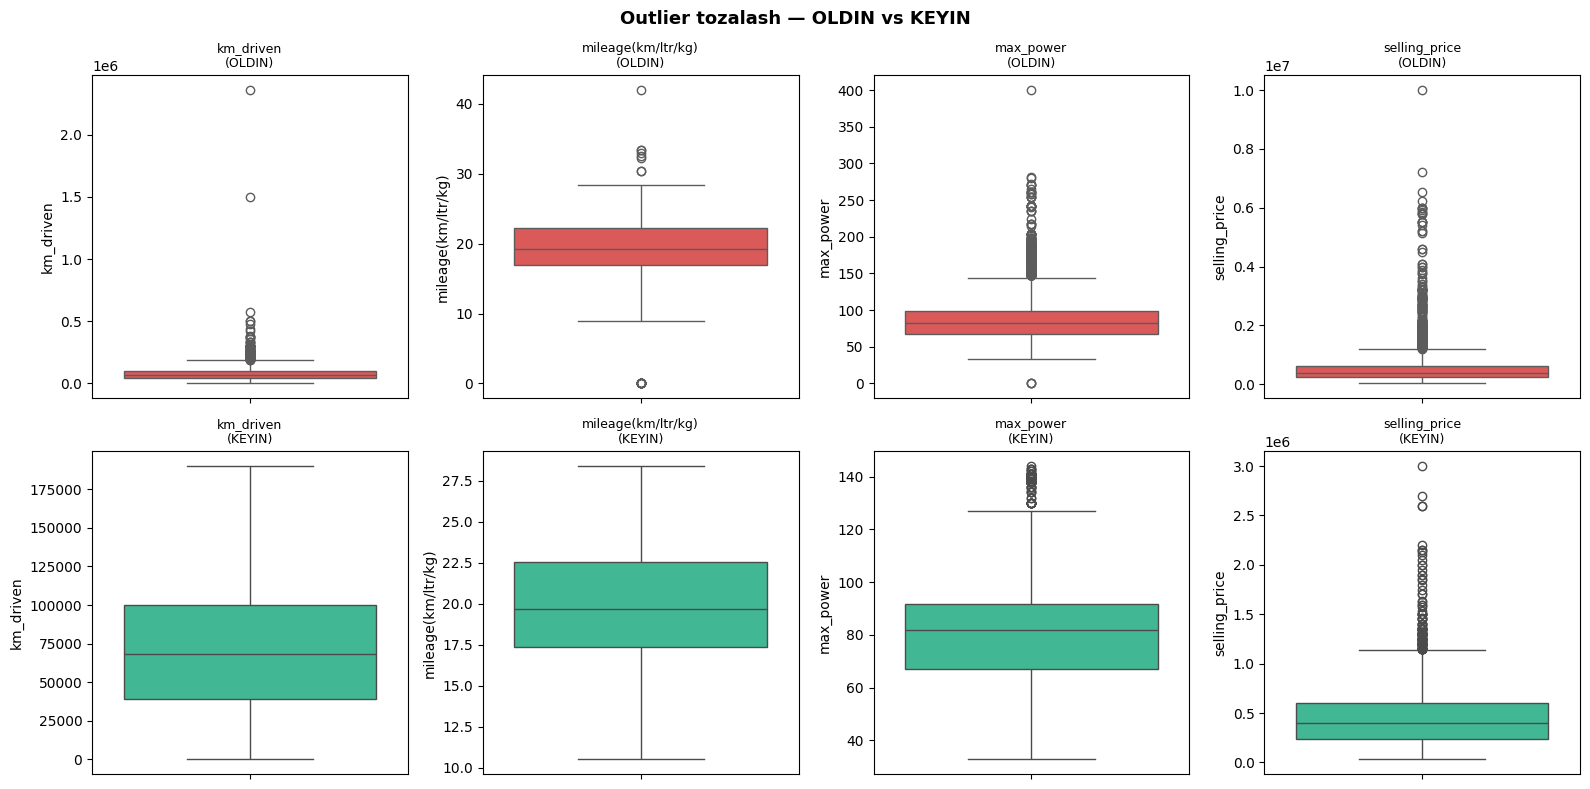

DATA CLEANING YAKUNIY HISOBOT
Boshlang'ich:     8128 qator, 12 ustun
Missing to'ldirildi: 4 ustun (median)
Duplicates olib tashlandi: 1202 ta
Outliers olib tashlandi:   555 ta
Yakuniy df_clean: 6371 qator, 12 ustun
Missing qolgan:  0 ta

df_clean.csv saqlandi ✅


In [14]:
# === BOXPLOT SOLISHTIRISH ===
cols_to_show = ['km_driven', 'mileage(km/ltr/kg)', 'max_power', 'selling_price']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(cols_to_show):
    # Oldin
    sns.boxplot(y=df[col], ax=axes[0][i], color='#EF4444')
    axes[0][i].set_title(f'{col}\n(OLDIN)', fontsize=9)

    # Keyin
    sns.boxplot(y=df_clean[col], ax=axes[1][i], color='#2ECB9B')
    axes[1][i].set_title(f'{col}\n(KEYIN)', fontsize=9)

plt.suptitle('Outlier tozalash — OLDIN vs KEYIN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# === YAKUNIY HISOBOT ===
print("=" * 40)
print("DATA CLEANING YAKUNIY HISOBOT")
print("=" * 40)
print(f"Boshlang'ich:     8128 qator, 12 ustun")
print(f"Missing to'ldirildi: 4 ustun (median)")
print(f"Duplicates olib tashlandi: 1202 ta")
print(f"Outliers olib tashlandi:   555 ta")
print(f"Yakuniy df_clean: {df_clean.shape[0]} qator, {df_clean.shape[1]} ustun")
print(f"Missing qolgan:  {df_clean.isnull().sum().sum()} ta")
print("=" * 40)

# === SAQLASH ===
df_clean.to_csv('car_price_clean.csv', index=False)
print("\ndf_clean.csv saqlandi ✅")

** EDA - Exploratory Data Analysis**



Shape: (6371, 12)

=== SELLING_PRICE STATISTIKA ===
count        6,371
mean       443,846
std        278,536
min         29,999
25%        240,000
50%        400,000
75%        600,000
max      3,000,000
Name: selling_price, dtype: object


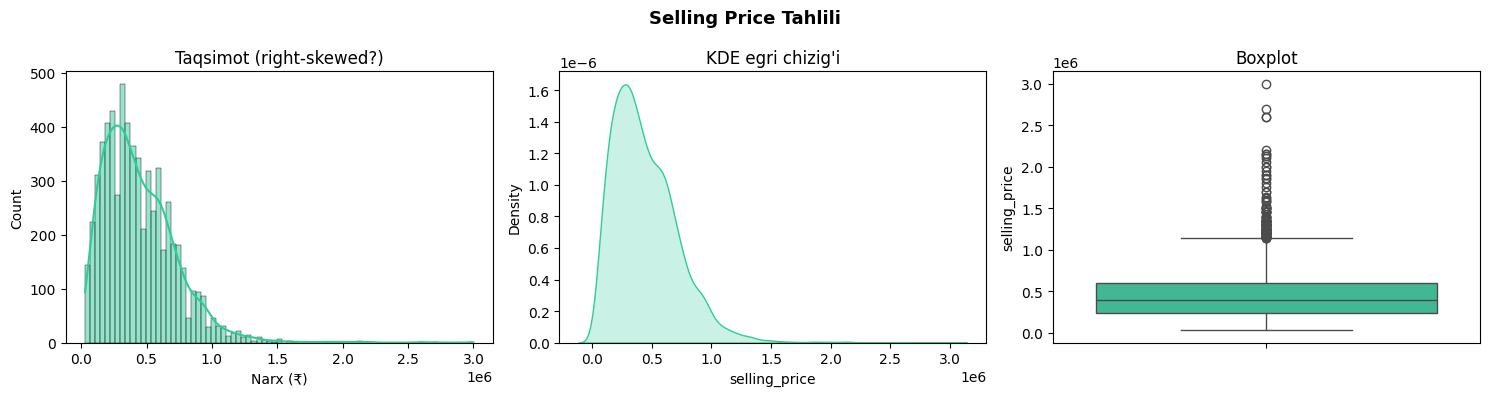

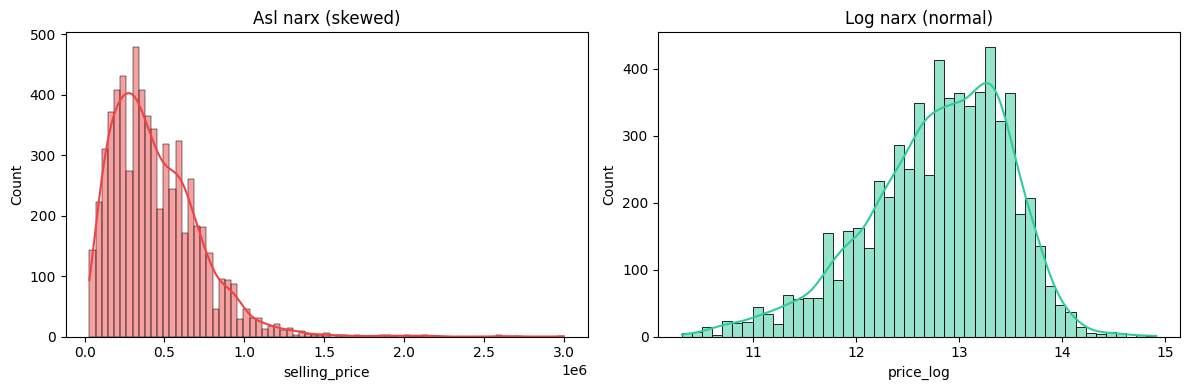

In [15]:
#1-QADAM — selling_price tahlili

# === EDA BOSHLASH ===
df = pd.read_csv('car_price_clean.csv')

print("Shape:", df.shape)
print("\n=== SELLING_PRICE STATISTIKA ===")
print(df['selling_price'].describe().apply(lambda x: f"{x:,.0f}"))

# === 3 TA GRAFIK: hist + kde + boxplot ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histogram
sns.histplot(df['selling_price'], ax=axes[0], color='#2ECB9B', kde=True)
axes[0].set_title('Taqsimot (right-skewed?)')
axes[0].set_xlabel('Narx (₹)')


# 2. KDE
sns.kdeplot(df['selling_price'], ax=axes[1], fill=True, color='#2ECB9B')
axes[1].set_title('KDE egri chizig\'i')

# 3. Boxplot
sns.boxplot(y=df['selling_price'], ax=axes[2], color='#2ECB9B')
axes[2].set_title('Boxplot')

plt.suptitle('Selling Price Tahlili', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# === LOG TRANSFORM ===
import numpy as np
df['price_log'] = np.log1p(df['selling_price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['selling_price'], ax=axes[0], color='#EF4444', kde=True)
axes[0].set_title('Asl narx (skewed)')
sns.histplot(df['price_log'], ax=axes[1], color='#2ECB9B', kde=True)
axes[1].set_title('Log narx (normal)')
plt.tight_layout()
plt.show()

=== SELLING_PRICE BILAN KORRELYATSIYA ===
price_log             0.904
year                  0.637
max_power             0.566
engine                0.377
seats                 0.250
mileage(km/ltr/kg)    0.082
km_driven            -0.271
Name: selling_price, dtype: float64


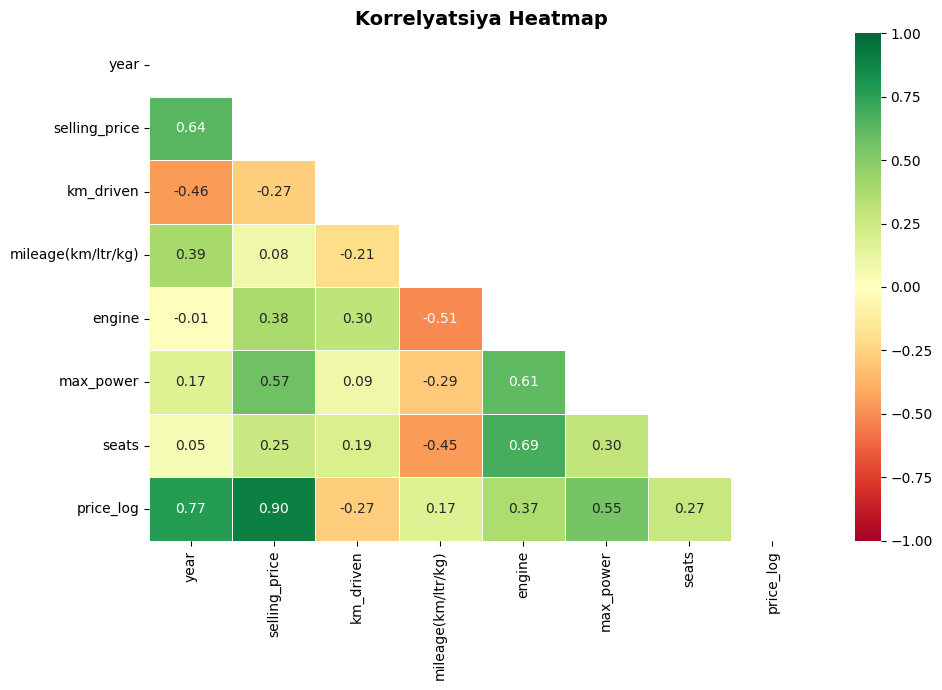

In [16]:
#2-QADAM — Korrelyatsiya Heatmap

# === KORRELYATSIYA ===
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

# selling_price bilan bog'liqlik
print("=== SELLING_PRICE BILAN KORRELYATSIYA ===")
sp_corr = corr['selling_price'].drop('selling_price').sort_values(ascending=False)
print(sp_corr.round(3))

# Heatmap
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Korrelyatsiya Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

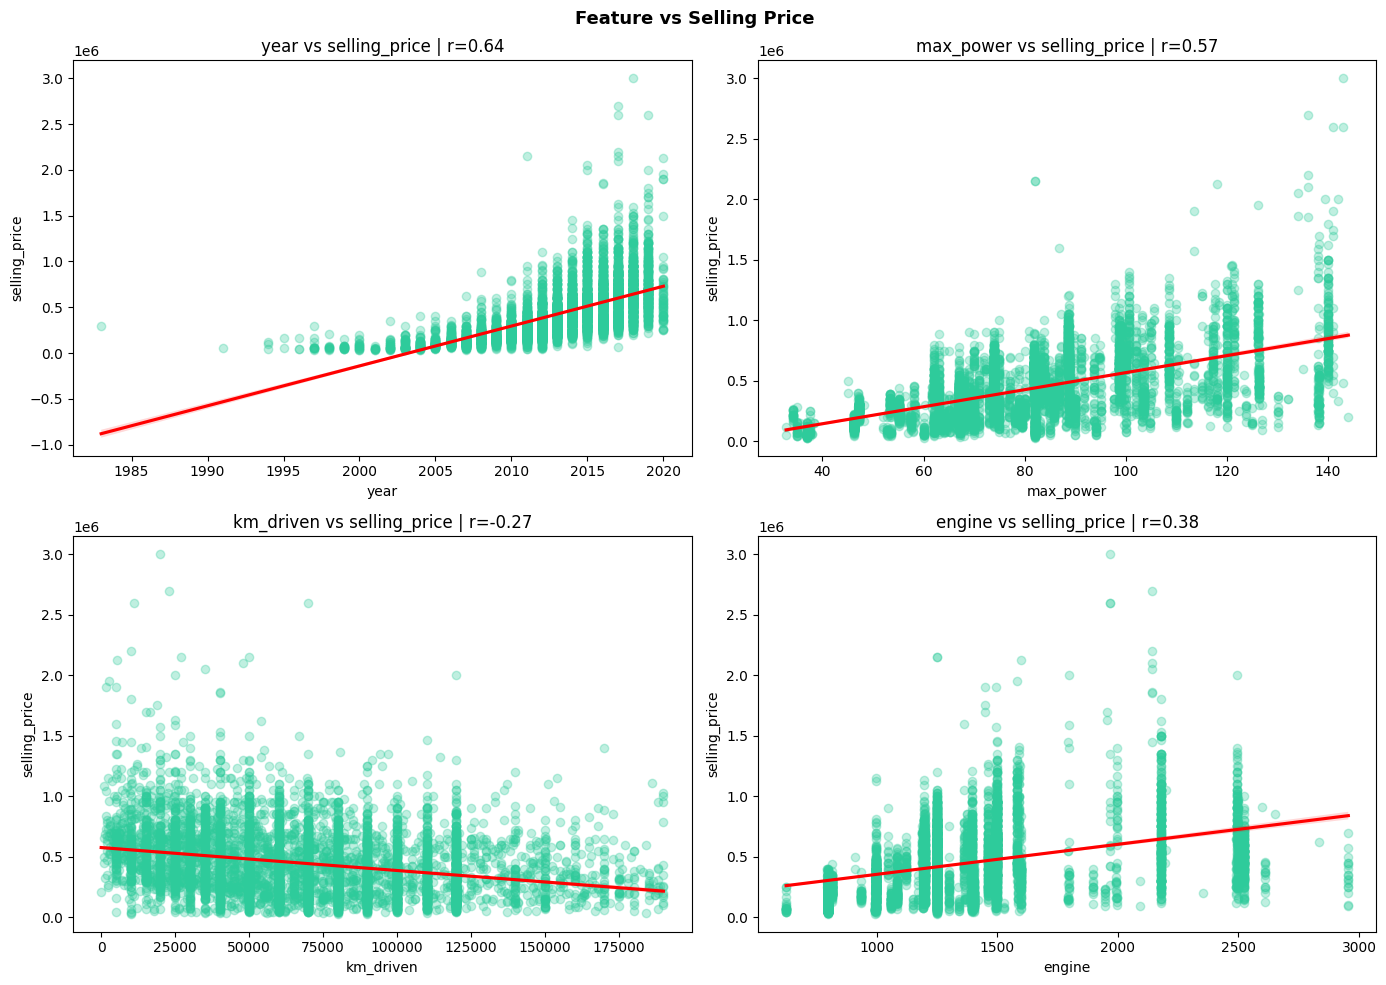

/tmp/ipykernel_900/3695646215.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuel_avg.index, y=fuel_avg.values, ax=axes[0], palette='Set2')
/tmp/ipykernel_900/3695646215.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trans_avg.index, y=trans_avg.values, ax=axes[1], palette='Set2')
/tmp/ipykernel_900/3695646215.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='owner', y='selling_price', order=owner_order,


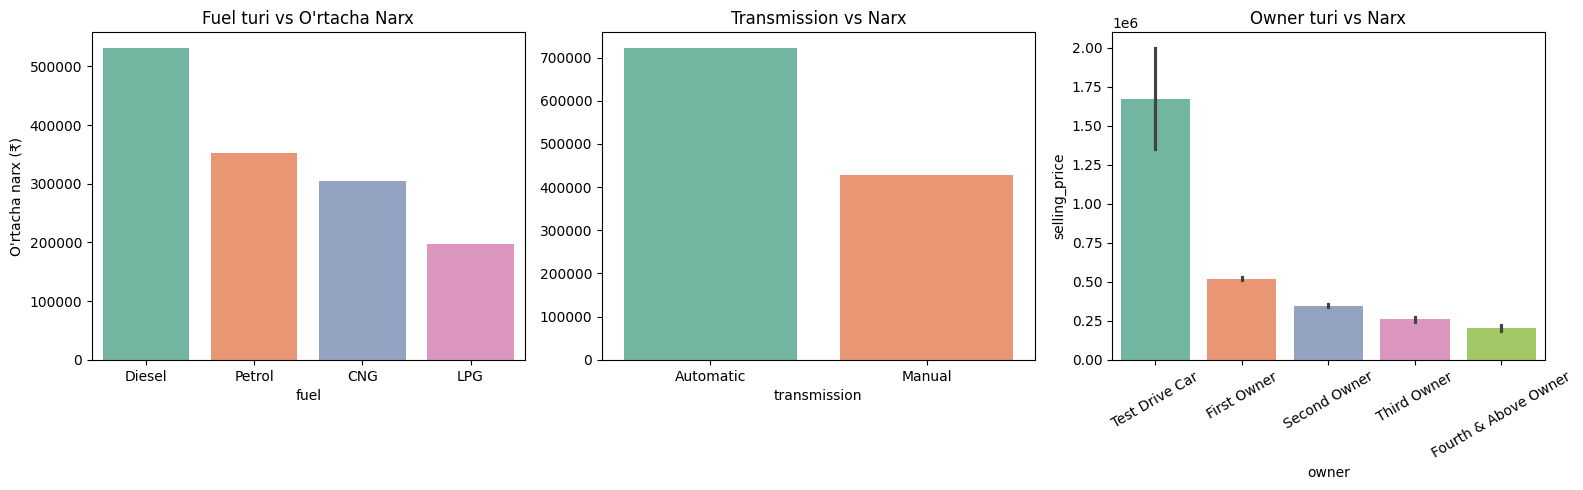

In [17]:
#3-QADAM — Scatter + Kategorik tahlil

# === SCATTER: TOP FEATURE vs SELLING_PRICE ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [
    ('year', 'selling_price'),
    ('max_power', 'selling_price'),
    ('km_driven', 'selling_price'),
    ('engine', 'selling_price'),
]

for ax, (x_col, y_col) in zip(axes.flatten(), pairs):
    sns.regplot(
        data=df, x=x_col, y=y_col, ax=ax,
        scatter_kws={'alpha': 0.3, 'color': '#2ECB9B'},
        line_kws={'color': 'red'}
    )
    r = df[x_col].corr(df[y_col])
    ax.set_title(f'{x_col} vs {y_col} | r={r:.2f}')

plt.suptitle('Feature vs Selling Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# === KATEGORIK TAHLIL ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Fuel turi bo'yicha o'rtacha narx
fuel_avg = df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False)
sns.barplot(x=fuel_avg.index, y=fuel_avg.values, ax=axes[0], palette='Set2')
axes[0].set_title('Fuel turi vs O\'rtacha Narx')
axes[0].set_ylabel('O\'rtacha narx (₹)')

# 2. Transmission bo'yicha
trans_avg = df.groupby('transmission')['selling_price'].mean().sort_values(ascending=False)
sns.barplot(x=trans_avg.index, y=trans_avg.values, ax=axes[1], palette='Set2')
axes[1].set_title('Transmission vs Narx')

# 3. Owner turi bo'yicha
owner_order = df.groupby('owner')['selling_price'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='owner', y='selling_price', order=owner_order,
            ax=axes[2], palette='Set2')
axes[2].set_title('Owner turi vs Narx')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

/tmp/ipykernel_900/726189153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='transmission', y='selling_price',
/tmp/ipykernel_900/726189153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='fuel', y='selling_price',


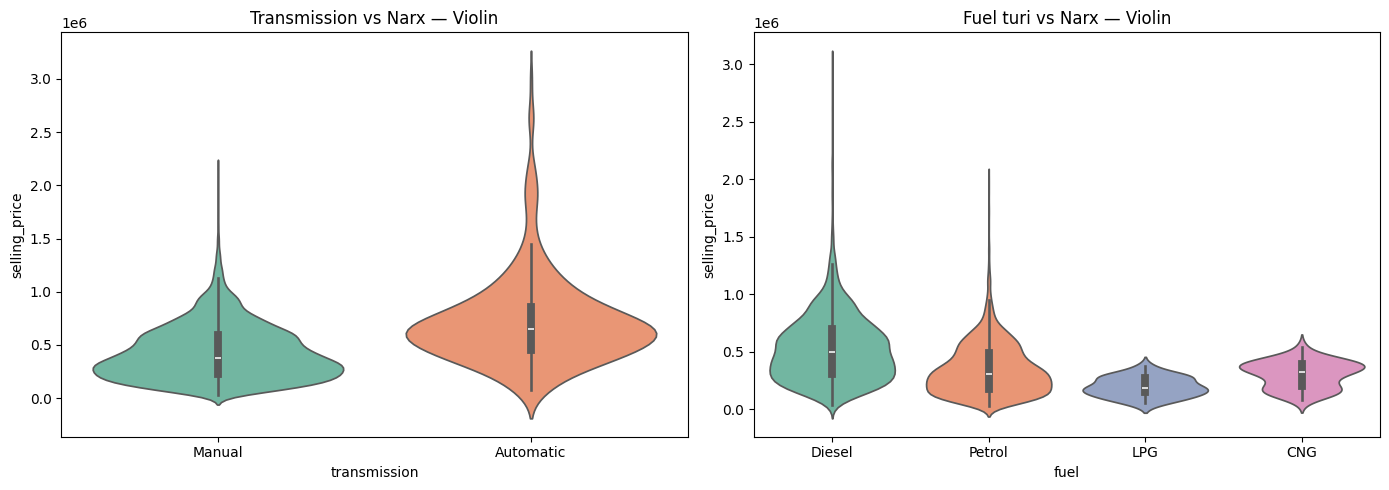

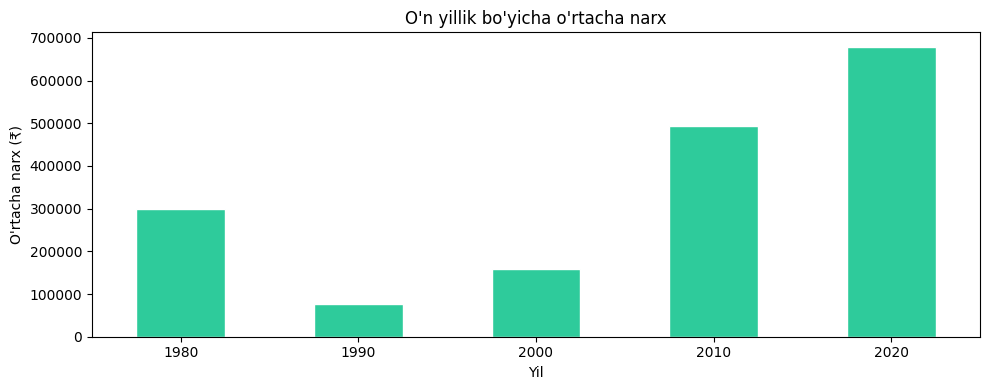

EDA YAKUNIY TOPILMALAR
1. Eng kuchli feature: year (r=0.64)
   → Yangi mashina = qimmatroq
2. max_power (r=0.57): kuchli dvigatel = narx yuqori
3. km_driven (r=-0.27): ko'p yurgan = arzonroq
4. Diesel mashinalar Petrol'dan o'rtacha qimmatroq
5. Automatic > Manual (narx bo'yicha)
6. First Owner mashinalar ikkinchi/uchinchi egadan qimmat
7. engine-seats o'rtasida multicollinearity (r=0.69)
   → Modelda faqat bittasini ishlatish tavsiya

df_clean tayyor: 6371 qator, 14 ustun
Keyingi qadam: Feature Engineering + ML Model!


In [18]:
#4-QADAM — Yakuniy EDA xulosa + Violin plot
# === VIOLIN: transmission vs selling_price ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='transmission', y='selling_price',
               palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('Transmission vs Narx — Violin')

sns.violinplot(data=df, x='fuel', y='selling_price',
               palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Fuel turi vs Narx — Violin')

plt.tight_layout()
plt.show()

# === YEAR bo'yicha trend (decade) ===
df['decade'] = (df['year'] // 10) * 10
decade_avg = df.groupby('decade')['selling_price'].mean()

plt.figure(figsize=(10, 4))
decade_avg.plot(kind='bar', color='#2ECB9B', edgecolor='white')
plt.title('O\'n yillik bo\'yicha o\'rtacha narx', fontsize=12)
plt.xlabel('Yil')
plt.ylabel('O\'rtacha narx (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# === YAKUNIY XULOSA ===
print("=" * 50)
print("EDA YAKUNIY TOPILMALAR")
print("=" * 50)
print(f"1. Eng kuchli feature: year (r=0.64)")
print(f"   → Yangi mashina = qimmatroq")
print(f"2. max_power (r=0.57): kuchli dvigatel = narx yuqori")
print(f"3. km_driven (r=-0.27): ko'p yurgan = arzonroq")
print(f"4. Diesel mashinalar Petrol'dan o'rtacha qimmatroq")
print(f"5. Automatic > Manual (narx bo'yicha)")
print(f"6. First Owner mashinalar ikkinchi/uchinchi egadan qimmat")
print(f"7. engine-seats o'rtasida multicollinearity (r=0.69)")
print(f"   → Modelda faqat bittasini ishlatish tavsiya")
print("=" * 50)
print(f"\ndf_clean tayyor: {df.shape[0]} qator, {df.shape[1]} ustun")
print("Keyingi qadam: Feature Engineering + ML Model!")